# UP Rice Farm Soil Carbon MRV Pipeline — Part 1: Geospatial & Remote Sensing

**Goal:** Build a per-farm NDVI dataset for a set of smallholder rice plots in Bahraich district, Uttar Pradesh, by combining hand-digitized farm boundaries (vector data) with Sentinel-2 satellite imagery (raster data).

This notebook covers:
1. Loading and cleaning farm boundary data (GeoPandas)
2. Pulling Sentinel-2 imagery via Google Earth Engine
3. Raster math to compute NDVI (Rasterio + NumPy)
4. Zonal statistics — NDVI per farm plot (rasterstats)
5. Visualization

This mirrors a core MRV (Measurement, Reporting, Verification) task: connecting satellite-derived vegetation indices to individual farmer plots without requiring on-ground GPS surveys of every field.


In [1]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show
from rasterstats import zonal_stats

DATA_DIR = "../data"


## 1. Load and clean farm boundary data

The raw boundaries were hand-digitized in geojson.io over a real agricultural area (Bahraich district, UP). Real-world digitized data is rarely clean on the first pass — this dataset had 2 broken/empty geometries (likely stray clicks) which needed to be dropped before any downstream analysis.

In [2]:
gdf_raw = gpd.read_file(f"{DATA_DIR}/up_rice_farms_clean.geojson")
print(f"Loaded {len(gdf_raw)} farm plots")
print(f"CRS: {gdf_raw.crs}")
gdf_raw.head()


Loaded 15 farm plots
CRS: EPSG:4326


,farm_id,area_ha,geometry
0,f001,1.836,"POLYGON ((81.93316 27.07886, 81.93352 27.07969..."
1,f002,1.639,"POLYGON ((81.933 27.08071, 81.93376 27.08159, ..."
2,f003,0.542,"POLYGON ((81.9316 27.08147, 81.93194 27.08208,..."
3,f004,0.564,"POLYGON ((81.93223 27.08257, 81.93239 27.08291..."
4,f005,0.744,"POLYGON ((81.93548 27.08183, 81.93606 27.08282..."


In [3]:
# Quick sanity check on plot sizes -- should be smallholder scale (roughly 0.1-5 ha)
print(gdf_raw['area_ha'].describe())


count    15.000000
mean      1.372933
std       0.783141
min       0.542000
25%       0.801500
50%       1.065000
75%       1.685000
max       3.440000
Name: area_ha, dtype: float64


## 2. Pull Sentinel-2 imagery via Google Earth Engine

Imagery was pulled using the Earth Engine Code Editor (JavaScript) and exported to Google Drive as a GeoTIFF. The Earth Engine script:

```javascript
var aoi = ee.Geometry.Rectangle([81.9107, 27.0720, 81.9411, 27.0950]);

var s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
  .filterBounds(aoi)
  .filterDate('2024-10-01', '2024-12-31')
  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
  .sort('CLOUDY_PIXEL_PERCENTAGE');

var image = s2.first().clip(aoi);

Export.image.toDrive({
  image: image.select(['B2', 'B3', 'B4', 'B8']),
  description: 'up_rice_farms_sentinel2',
  folder: 'varaha_prep',
  region: aoi,
  scale: 10,
  crs: 'EPSG:4326',
  maxPixels: 1e9
});
```

This pulls the least-cloudy Sentinel-2 image available in the date window, and exports 4 bands (Blue, Green, Red, Near-Infrared) at native 10m resolution.

In [4]:
with rasterio.open(f"{DATA_DIR}/up_rice_farms_sentinel2.tif") as src:
    print("Raster CRS:", src.crs)
    print("Raster shape (width, height):", src.width, src.height)
    print("Bands:", src.count)
    print("Resolution (deg/pixel):", src.res)
    print("Bounds:", src.bounds)


Raster CRS: EPSG:4326
Raster shape (width, height): 340 257
Bands: 4
Resolution (deg/pixel): (8.983152841195215e-05, 8.983152841195215e-05)
Bounds: BoundingBox(left=81.91063339422827, bottom=27.071988728339544, right=81.94117611388833, top=27.095075431141417)


## 3. Check CRS alignment (reprojection check)

Before any raster/vector overlay operation, it's important to explicitly verify both datasets share the same coordinate reference system rather than assuming it — a mismatch here would silently produce wrong zonal statistics.

In [5]:
with rasterio.open(f"{DATA_DIR}/up_rice_farms_sentinel2.tif") as src:
    raster_crs = src.crs

vector_crs = gdf_raw.crs

print(f"Raster CRS: {raster_crs}")
print(f"Vector CRS: {vector_crs}")

if raster_crs != vector_crs:
    print("Mismatch detected -- reprojecting vector to match raster")
    gdf_raw = gdf_raw.to_crs(raster_crs)
else:
    print("CRS already aligned -- no reprojection needed")


Raster CRS: EPSG:4326
Vector CRS: EPSG:4326
CRS already aligned -- no reprojection needed


## 4. Compute NDVI (raster math)

NDVI (Normalized Difference Vegetation Index) uses the contrast between Near-Infrared (B8) and Red (B4) reflectance to measure vegetation health:

$$NDVI = \frac{NIR - Red}{NIR + Red}$$

Healthy vegetation strongly reflects NIR and absorbs Red (for photosynthesis), producing NDVI values closer to 1. Bare soil, water, or stressed vegetation produce lower or negative values.

In [6]:
with rasterio.open(f"{DATA_DIR}/up_rice_farms_sentinel2.tif") as src:
    red = src.read(3).astype("float32")   # Band 4 = Red
    nir = src.read(4).astype("float32")   # Band 8 = Near-Infrared
    profile = src.profile

np.seterr(divide="ignore", invalid="ignore")
ndvi = (nir - red) / (nir + red)
ndvi = np.where((nir + red) == 0, np.nan, ndvi)  # guard against divide-by-zero

print(f"NDVI range: {np.nanmin(ndvi):.3f} to {np.nanmax(ndvi):.3f}")
print(f"NDVI mean: {np.nanmean(ndvi):.3f}")


NDVI range: -0.210 to 0.793
NDVI mean: 0.219


In [7]:
# Save NDVI as its own georeferenced raster (needed for zonal stats)
ndvi_profile = profile.copy()
ndvi_profile.update(count=1, dtype="float32", nodata=np.nan)

with rasterio.open(f"{DATA_DIR}/ndvi_output.tif", "w", **ndvi_profile) as dst:
    dst.write(ndvi, 1)

print("NDVI raster saved")


NDVI raster saved


## 5. Zonal statistics — NDVI per farm plot

This is the core geospatial operation: for each farm polygon, summarize the NDVI pixel values that fall within its boundary. This converts one large satellite image into a per-farmer vegetation score.

In [8]:
stats = zonal_stats(
    gdf_raw,
    f"{DATA_DIR}/ndvi_output.tif",
    stats=["mean", "min", "max", "std", "count"],
    nodata=float("nan")
)

gdf = gdf_raw.copy()
for i, s in enumerate(stats):
    gdf.loc[i, "ndvi_mean"] = s["mean"]
    gdf.loc[i, "ndvi_min"] = s["min"]
    gdf.loc[i, "ndvi_max"] = s["max"]
    gdf.loc[i, "ndvi_std"] = s["std"]
    gdf.loc[i, "pixel_count"] = s["count"]

gdf[["farm_id", "area_ha", "ndvi_mean", "ndvi_min", "ndvi_max", "pixel_count"]].round(3)


,farm_id,area_ha,ndvi_mean,ndvi_min,ndvi_max,pixel_count
0,f001,1.836,0.172,0.113,0.392,208.0
1,f002,1.639,0.149,0.109,0.385,185.0
2,f003,0.542,0.181,0.122,0.500,61.0
3,f004,0.564,0.167,0.106,0.424,67.0
4,f005,0.744,0.229,0.143,0.295,83.0
5,f006,2.388,0.125,0.097,0.164,270.0
6,f007,0.937,0.511,0.223,0.682,106.0
7,f008,1.028,0.135,0.104,0.315,115.0
8,f009,0.778,0.158,0.112,0.228,88.0
9,f010,1.065,0.138,0.107,0.277,124.0


**Observations:**
- Most plots show NDVI in the 0.12-0.24 range, on the lower end for actively growing vegetation. Since the imagery window was Oct-Dec, this most likely reflects post-harvest or early-sowing conditions rather than a data quality issue -- worth cross-checking against a peak-growth season image or ground truth in a production setting.
- Plot `f007` stands out with a notably higher mean NDVI (~0.51) relative to its neighbors -- the kind of anomaly a real MRV analyst would flag for investigation (different crop stage, irrigation difference, or a boundary digitization issue).
- `pixel_count` varies with plot size (61 to 388 pixels) -- smaller plots have fewer pixels contributing to their statistics, and therefore less statistical reliability, which matters when setting confidence thresholds in a real verification pipeline.

In [9]:
gdf.to_file(f"{DATA_DIR}/up_rice_farms_with_ndvi_final.geojson", driver="GeoJSON")
print("Saved farm plots with NDVI statistics")


Saved farm plots with NDVI statistics

## 6. Visualization

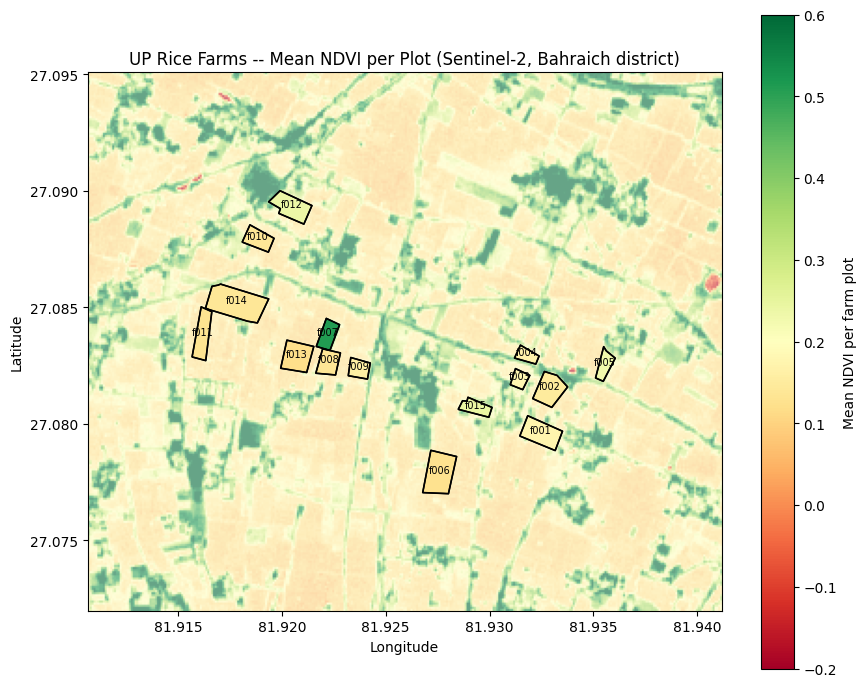

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

with rasterio.open(f"{DATA_DIR}/ndvi_output.tif") as src:
    show(src, ax=ax, cmap="RdYlGn", vmin=-0.2, vmax=0.6, alpha=0.6)

gdf.boundary.plot(ax=ax, color="black", linewidth=1)
gdf.plot(
    column="ndvi_mean", ax=ax, cmap="RdYlGn", vmin=-0.2, vmax=0.6,
    edgecolor="black", linewidth=1.2, legend=True,
    legend_kwds={"label": "Mean NDVI per farm plot"}
)

for idx, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row["farm_id"], (centroid.x, centroid.y), fontsize=7, ha="center", color="black")

ax.set_title("UP Rice Farms -- Mean NDVI per Plot (Sentinel-2, Bahraich district)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("ndvi_choropleth.png", dpi=150)
plt.show()


## Summary

| Step | Tool | Output |
|---|---|---|
| Load & clean farm boundaries | GeoPandas | 15 valid farm plots, 0.5-3.4 ha each |
| Pull Sentinel-2 imagery | Google Earth Engine | 4-band GeoTIFF, 10m resolution |
| Verify CRS alignment | GeoPandas + Rasterio | Confirmed EPSG:4326 match |
| Compute NDVI | Rasterio + NumPy | Single-band NDVI raster |
| Zonal statistics | rasterstats | Per-farm NDVI mean/min/max/std |
| Visualization | Matplotlib | NDVI choropleth map |

**Next steps:** feed farm-level NDVI trends into a process-based soil carbon model (RothC) to estimate SOC sequestration -- covered in Part 2 of this pipeline.
